# Ejemplar: Construir un modelo de Naive Bayes


## Introducción

En esta actividad, construirás tu propio modelo de Naive Bayes. Los modelos de Naive Bayes pueden ser valiosos para usar en cualquier momento que estés haciendo trabajo con predicciones porque te dan una forma de tener en cuenta información nueva. En el mundo de hoy, donde los datos están en constante evolución, modelar con Naive Bayes puede ayudarte a adaptarte rápidamente y hacer predicciones más precisas sobre lo que podría ocurrir.

Para esta actividad, trabajas para una empresa que proporciona ideas para la gestión y entrenadores en la Asociación Nacional de Baloncesto (NBA), una liga profesional de baloncesto en Norteamérica. La liga está interesada en retener a los jugadores que puedan durar en el entorno de alta presión del baloncesto profesional y ayudar al equipo a tener éxito con el tiempo. En la actividad anterior, analizaste un subconjunto de datos que contenía información sobre los jugadores de la NBA y sus registros de rendimiento. Realizaste ingeniería de características para determinar qué características serían más efectivas para predecir la duración de la carrera de un jugador. Ahora usarás esas ideas para construir un modelo que predice si un jugador tendrá una carrera en la NBA de cinco años o más.

Los datos para esta actividad consisten en estadísticas de rendimiento de cada jugador en su año de novato. Hay 1,341 observaciones, y cada observación en los datos representa a un jugador diferente en la NBA. Tu variable objetivo es un valor booleano que indica si un jugador dado durará en la liga cinco años. Dado que anteriormente realizaste ingeniería de características en estos datos, ahora están listos para modelar.


## Paso 1: Importaciones


### Importar paquetes

Comience con sus declaraciones de importación. De particular interés aquí son `pandas` y de `sklearn`, `naive_bayes`, `model_selection`, y `metrics`.


In [1]:
# Import relevant libraries and modules.

import pandas as pd
from sklearn import naive_bayes
from sklearn import model_selection
from sklearn import metrics

### Cargar el conjunto de datos

Recuerda que en el laboratorio sobre ingeniería de características, generaste características para el conjunto de datos de jugadores de la NBA junto con la variable objetivo ``target_5yrs``. Los datos fueron importados como un DataFrame llamado `extracted_data`. Como se muestra en esta celda, el conjunto de datos ha sido cargado automáticamente para ti. No necesitas descargar el archivo .csv, ni proporcionar más código, para acceder al conjunto de datos y continuar con este laboratorio. Por favor, continúa con esta actividad completando las siguientes instrucciones.


In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.
# Load extracted_nba_players_data.csv into a DataFrame called extracted_data.

extracted_data = pd.read_csv('extracted_nba_players_data.csv')

### Mostrar los datos

Revisar las primeras 10 filas de datos.


In [3]:
# Display the first 10 rows of data.

### YOUR CODE HERE ###

extracted_data.head(10)

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304
5,42.3,32.5,73.2,0.8,1.8,0.4,0.0,0.7,0,277.5,0.324561
6,43.5,50.0,81.1,2.0,0.6,0.2,0.1,0.7,1,409.2,0.605505
7,41.5,30.0,87.5,1.7,0.2,0.2,0.1,0.7,1,273.6,0.553398
8,39.2,23.3,71.4,0.8,2.3,0.3,0.0,1.1,0,156.0,0.242424
9,38.3,21.4,67.8,1.1,0.3,0.2,0.0,0.7,0,155.4,0.435294


## Paso 2: Preparación del modelo


### Aisla tus variables objetivo y predictoras
Define por separado la variable objetivo (`target_5yrs`) y las características.


In [4]:
# Define the y (target) variable.

### YOUR CODE HERE ###
y = extracted_data['target_5yrs']

# Define the X (predictor) variables.

### YOUR CODE HERE ###
X = extracted_data.drop('target_5yrs', axis = 1)

<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Consulte [el contenido sobre dividir sus datos en X e y](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/VxbUT/construct-a-naive-bayes-model-with-python).
</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

En `pandas`, selecciona tu DataFrame usando corchetes `[]` para especificar qué columna(s) seleccionar.
</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Rápidamente selecciona un subconjunto de un DataFrame para excluir una columna en particular usando la función `drop()` y especificando la columna a eliminar.
</details>


### Mostrar las primeras 10 filas de tus datos objetivo

Mostrar las primeras 10 filas de tus variables objetivo y predictoras. Esto te ayudará a tener una idea de cómo está estructurada la data.


In [5]:
# Display the first 10 rows of your target data.

### YOUR CODE HERE ###

y.head(10)

0    0
1    0
2    0
3    1
4    1
5    0
6    1
7    1
8    0
9    0
Name: target_5yrs, dtype: int64

**Pregunta:** ¿Qué observas acerca de tu variable objetivo?

Dado que la variable objetivo contiene tanto 1 como 0, indica que es binaria y requiere un modelo adecuado para clasificación binaria.


In [6]:
# Display the first 10 rows of your predictor variables.

### YOUR CODE HERE ###

X.head(10)

,fg,3p,ft,reb,ast,stl,blk,tov,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,216.0,0.391304
5,42.3,32.5,73.2,0.8,1.8,0.4,0.0,0.7,277.5,0.324561
6,43.5,50.0,81.1,2.0,0.6,0.2,0.1,0.7,409.2,0.605505
7,41.5,30.0,87.5,1.7,0.2,0.2,0.1,0.7,273.6,0.553398
8,39.2,23.3,71.4,0.8,2.3,0.3,0.0,1.1,156.0,0.242424
9,38.3,21.4,67.8,1.1,0.3,0.2,0.0,0.7,155.4,0.435294


**Pregunta:** ¿Qué observas acerca de tus variables predictoras?

Los datos indican que todas las variables predictoras son valores numéricos continuos, por lo que es importante que el modelo seleccionado sea adecuado para características continuas.


### Realizar una operación de división en tus datos

Divide tus datos en un conjunto de entrenamiento (75% de los datos) y un conjunto de prueba (25% de los datos). Este es un paso importante en el proceso, ya que te permite reservar una parte de los datos que el modelo no ha observado. Esto prueba qué tan bien generaliza el modelo—o qué tan bien funciona—en datos nuevos.


In [7]:
# Perform the split operation on your data.
# Assign the outputs as follows: X_train, X_test, y_train, y_test.

### YOUR CODE HERE ###

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, random_state=0)

<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Consulte [el contenido sobre dividir sus datos entre un conjunto de entrenamiento y un conjunto de prueba](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/VxbUT/construct-a-naive-bayes-model-with-python).
</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

Llama a la función en el módulo `model_selection` de `sklearn` en las características y la variable objetivo, para realizar la división.
</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Llamar a la función `model_selection.train_test_split()`, pasando tanto `features` como `target`, mientras se configura el `test_size` apropiado.

Asignar la salida de esta división como `X_train`, `X_test`, `y_train`, `y_test`.
</details>


### Imprimir la forma de cada salida

Imprimir la forma de cada salida de tu división de entrenamiento y prueba. Esto verificará que la división funcionó como se esperaba.


In [8]:
# Print the shape (rows, columns) of the output from the train-test split.

# Print the shape of X_train.

### YOUR CODE HERE ###

print(X_train.shape)

# Print the shape of X_test.

### YOUR CODE HERE ###

print(X_test.shape)

# Print the shape of y_train.

### YOUR CODE HERE ###

print(y_train.shape)

# Print the shape of y_test.

### YOUR CODE HERE ###

print(y_test.shape)

(1005, 10)
(335, 10)
(1005,)
(335,)


<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Llama al atributo que los DataFrames en `pandas` tienen para obtener el número de filas y el número de columnas como una tupla.
</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

Llamar al atributo `shape`.
</details>


**Pregunta:** ¿Cuántas filas hay en cada una de las salidas?

Cada DataFrame de entrenamiento contiene 1,005 filas, mientras que cada DataFrame de prueba contiene 335 filas. Además, hay 10 columnas en cada DataFrame X, con solo una columna en cada DataFrame y.


**Pregunta:** ¿Cuál fue el efecto de la división entre entrenamiento y prueba?

El efecto de la división entre entrenamiento y prueba mostró una división aproximadamente del 75% para entrenamiento y del 25% para prueba.


## Paso 3: Construcción del modelo


**Pregunta:** ¿Qué algoritmo de Naive Bayes deberías usar?

Usando la suposición de que tus características son normalmente distribuidas y continuas, el algoritmo de Naive Bayes Gaussiano es el más apropiado para tus datos. Aunque tus datos pueden no adherirse perfectamente a estas suposiciones, este modelo seguirá proporcionando los resultados más útiles y precisos.


<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Consulte [el contenido sobre diferentes implementaciones del Naive Bayes](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/supplement/1zfDy/naive-bayes-classifiers) para determinar cuál es apropiada en esta situación.
</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

Tenga en cuenta que está realizando clasificación binaria.
</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Puedes identificar el algoritmo apropiado para usar porque estás realizando una clasificación binaria y asumiendo que las características de tu modelo siguen una distribución normal.
</details>


### Ajusta tu modelo a tus datos de entrenamiento y predice en tus datos de prueba

Al crear tu modelo, estarás aprovechando tu trabajo de ingeniería de características entrenando el clasificador en el DataFrame `X_train`. Utilizarás esto para predecir `target_5yrs` a partir de `y_train`.

Comienza definiendo `nb` como el algoritmo relevante de `sklearn`.`naive_bayes`. Luego ajusta tu modelo a tus datos de entrenamiento. Usa este modelo ajustado para crear predicciones para tus datos de prueba.


In [9]:
# Assign `nb` to be the appropriate implementation of Naive Bayes.

### YOUR CODE HERE ###

nb = naive_bayes.GaussianNB()

# Fit the model on your training data.

### YOUR CODE HERE ###

nb.fit(X_train, y_train)

# Apply your model to predict on your test data. Call this "y_pred".

### YOUR CODE HERE ###

y_pred = nb.predict(X_test)

<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Consulte [el contenido sobre la construcción de un Naive Bayes](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/VxbUT/construct-a-naive-bayes-model-with-python).
</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

La implementación apropiada en este caso es `naive_bayes`.`GaussianNB()`. Ajusta este modelo a tus datos de entrenamiento y predice en tus datos de prueba.
</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Llama a `fit()` y pasa tu conjunto de características de entrenamiento y variable objetivo. Luego llama a `predict()` en tu conjunto de características de prueba.
</details>


## Paso 4: Resultados y evaluación


### Aprovechar métricas para evaluar el rendimiento de tu modelo

Para evaluar los datos generados por tu modelo, puedes aprovechar una serie de métricas y técnicas de evaluación de scikit-learn examinando los valores observados reales en el conjunto de prueba en relación con la predicción de tu modelo. Específicamente, imprime la puntuación de precisión, puntuación de precisión, puntuación de recuperación y puntuación f1 asociadas con tus datos de prueba y valores predichos.


In [10]:
# Print your accuracy score.

### YOUR CODE HERE ###

print('accuracy score:'), print(metrics.accuracy_score(y_test, y_pred))

# Print your precision score.

### YOUR CODE HERE ###

print('precision score:'), print(metrics.precision_score(y_test, y_pred))

# Print your recall score.

### YOUR CODE HERE ###

print('recall score:'), print(metrics.recall_score(y_test, y_pred))

# Print your f1 score.

### YOUR CODE HERE ###

print('f1 score:'), print(metrics.f1_score(y_test, y_pred))

accuracy score:
0.6895522388059702
precision score:
0.8405797101449275
recall score:
0.5858585858585859
f1 score:
0.6904761904761905


(None, None)

<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

Consulte [el contenido sobre evaluación de modelos](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/EITmV/key-evaluation-metrics-for-classification-models) para obtener detalles sobre estas métricas.
</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

El módulo `metrics` en `sklearn` tiene una función para calcular cada una de estas métricas.
</details>


<details>
<summary><h4><strong>Pista 3</strong></h4></summary>

Llamar a `accuracy_score()`, `precision_score()`, `recall_score()`, y `f1_score()`, pasando `y_test`, y `y_pred` en cada función.
</details>


**Pregunta:** ¿Cuál es la puntuación de precisión para tu modelo, y qué te dice esto sobre el éxito del rendimiento del modelo?

La puntuación de precisión para este modelo es 0.6896, o 69.0% preciso.


**Pregunta:** ¿Puedes evaluar el éxito de tu modelo usando exclusivamente la puntuación de precisión?

En problemas de clasificación, la precisión es útil de saber pero puede no ser la mejor métrica para evaluar este modelo. Aunque la precisión suele ser la métrica más intuitiva, es una métrica de evaluación pobre en algunos casos. En particular, si tienes clases desequilibradas, un modelo podría parecer preciso pero ser pobre en equilibrar falsos positivos y falsos negativos.


**Pregunta:** ¿Cuáles son las puntuaciones de precisión y recall para tu modelo, y qué significan? ¿Es una de estas puntuaciones más precisa que la otra?

Las puntuaciones de precisión y recall son ambas útiles para evaluar la capacidad predictiva correcta de un modelo porque equilibran los falsos positivos y falsos negativos inherentes a la predicción.

El modelo muestra una puntuación de precisión de 0.8406, sugiriendo que el modelo es bastante bueno para predecir verdaderos positivos—lo que significa que el jugador jugará más de cinco años—mientras equilibra los falsos positivos. La puntuación de recall de 0.5859 muestra un peor rendimiento en la predicción de verdaderos negativos—donde el jugador no jugará por cinco años o más—mientras equilibra los falsos negativos. Estas dos métricas combinadas pueden dar una mejor evaluación del rendimiento del modelo que la precisión por sí sola.


**Pregunta:** ¿Cuál es la puntuación F1 de tu modelo, y qué significa esta puntuación?

La puntuación F1 equilibra el rendimiento de precisión y recall para dar una evaluación combinada de qué tan bien este modelo entrega predicciones. En este caso, la puntuación F1 es 0.6905, lo que sugiere un poder predictivo razonable en este modelo.


### Claridad con la matriz de confusión

Recuerda que una matriz de confusión es un gráfico que muestra los verdaderos y falsos positivos y negativos de tu modelo. Ayuda a crear una representación visual de los componentes que alimentan las métricas.

Crea una matriz de confusión basada en tus valores predichos para el conjunto de prueba.


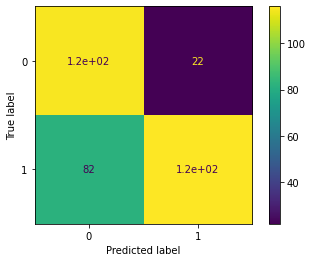

In [11]:
# Construct and display your confusion matrix.

# Construct the confusion matrix for your predicted and test values.

### YOUR CODE HERE ###

cm = metrics.confusion_matrix(y_test, y_pred)

# Create the display for your confusion matrix.

### YOUR CODE HERE ###

disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)

# Plot the visual in-line.

### YOUR CODE HERE ###

disp.plot()

<details>
<summary><h4><strong>Pista 1</strong></h4></summary>

El módulo `metrics` tiene funciones para crear una matriz de confusión.
</details>


<details>
<summary><h4><strong>Pista 2</strong></h4></summary>

Llama a `confusion_matrix`, pasando `y_test` y `y_pred`. Luego, utiliza `ConfusionMatrixDisplay()` para mostrar tu matriz de confusión.
</details>


Pregunta: ¿Qué notas al observar tu matriz de confusión, y esto se correlaciona con alguno de tus otros cálculos?

- La diagonal de arriba a la izquierda a abajo a la derecha en la matriz de confusión representa las predicciones correctas, y la proporción de estos cuadrados muestra la precisión.

- La concentración de verdaderos positivos destaca en relación con los falsos positivos. Esta proporción es la razón por la cual la puntuación de precisión es tan alta (0.8406).

- Los verdaderos negativos y los falsos negativos están más cercanos en número, lo que explica la peor puntuación de recall.


## Consideraciones

**¿Cuáles son algunos aspectos clave que aprendiste de este laboratorio?**
- La evaluación del modelo es importante para informar si el modelo ha entregado predicciones precisas.
- Dividir los datos fue importante para asegurar que hubiera datos nuevos para que el modelo probara su rendimiento predictivo.
- Cada métrica proporcionó una evaluación desde un punto de vista diferente, y la precisión sola no era una forma sólida de evaluar el modelo.
- Las evaluaciones efectivas equilibran los verdaderos/falsos positivos versus los verdaderos/falsos negativos a través de la matriz de confusión y la puntuación F1.

**¿Cómo presentarías tus resultados a tu equipo?**
- Mostrar los datos utilizados para crear la predicción y el rendimiento del modelo en general.
- Revisar la salida de muestra de las características y la matriz de confusión para indicar el rendimiento del modelo.
- Resaltar los valores de las métricas, enfatizando la puntuación F1.

**¿Cómo resumirías tus hallazgos a los interesados?**
- El modelo creado proporciona algún valor en predecir las posibilidades de un jugador de la NBA de jugar cinco años o más.
- Notablemente, el modelo tuvo un mejor rendimiento en predecir verdaderos positivos que en predecir verdaderos negativos. En otras palabras, identificó con mayor precisión a aquellos jugadores que probablemente jugarán más de cinco años que a aquellos que probablemente no lo harán.


**¡Felicidades!** Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa con tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo ha sido registrado
